# RHINO full-Stokes beam

CST far-field exports (1° grid, columns `Theta, Phi, Abs(Dir.), Abs(Theta), Phase(Theta), Abs(Phi), Phase(Phi), Ax.Ratio`) give the complex $(E_\theta, E_\phi)$; the Stokes beams are $B_p = \mathrm{Re}\,[E^\dagger \sigma_p E]$, $p \in \{I, Q, U, V\}$. The exports are not in the repository: set `CST_ROOT`.

In [1]:
from pathlib import Path

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

from tibec import E_field, pauli_array

CST_ROOT = Path("~/Dataspace/RHINO/CST_beams").expanduser()
MODEL = "HornDryGround"        # HornDry | HornWet | HornDryGround | HornWetGround
FREQS = [60, 70, 80]           # MHz; exports cover 55-85 MHz in 0.5 MHz steps
K = 1                          # index into FREQS used for the maps
LAT = np.deg2rad(53.2367)      # Jodrell Bank
HORN_X = [1, 0, 0]             # CST +x axis in (South, East, Zenith); assumed
STOKES = "IQUV"


def load_cst(model, freqs):
    """CST exports -> phi, theta [rad] and E[freq, phi, theta, (E_theta, E_phi)]."""
    E = []
    for f in freqs:
        t = np.loadtxt(CST_ROOT / model / f"{model}{f:g}.txt", skiprows=2)
        theta, phi = np.unique(t[:, 0]), np.unique(t[:, 1])
        e = 10 ** (t[:, [3, 5]] / 20) * np.exp(1j * np.deg2rad(t[:, [4, 6]]))  # dBi, deg -> complex
        e = e.reshape(phi.size, theta.size, 2)                                 # theta runs fastest
        E.append(np.concatenate([e, e[:1]]))                                   # repeat phi = 0 at 360 deg
    return np.deg2rad(np.append(phi, 360.0)), np.deg2rad(theta), np.array(E)


phi, theta, E = load_cst(MODEL, FREQS)
up = theta <= np.pi / 2
E.shape

(3, 361, 181, 2)

## Antenna frame

Ludwig-3 basis $(\hat x, \hat y)$ of the CST model, boresight at the centre, radius $=\theta$. $Q, U, V$ in units of peak $I$.

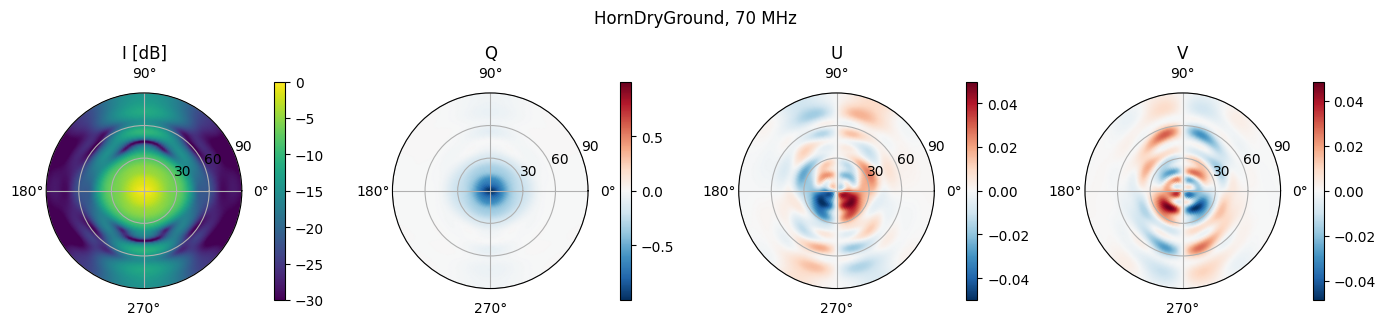

In [2]:
c, s = np.cos(phi)[:, None], np.sin(phi)[:, None]
E_xy = np.stack([c * E[K, ..., 0] - s * E[K, ..., 1],      # (E_theta, E_phi) -> (E_x, E_y)
                 s * E[K, ..., 0] + c * E[K, ..., 1]], -1)
S = np.einsum("...l,plm,...m->p...", E_xy.conj(), pauli_array, E_xy).real
S /= S[0].max()

fig, axs = plt.subplots(1, 4, figsize=(14, 3.4), subplot_kw={"projection": "polar"})
for p, ax in enumerate(axs):
    m = (10 * np.log10(S[0]) if p == 0 else S[p])[:, up]
    lim = np.abs(m).max()
    kw = dict(cmap="viridis", vmin=-30, vmax=0) if p == 0 else dict(cmap="RdBu_r", vmin=-lim, vmax=lim)
    im = ax.pcolormesh(phi, np.rad2deg(theta[up]), m.T, shading="gouraud", **kw)
    ax.set(title="I [dB]" if p == 0 else STOKES[p], yticks=[30, 60, 90], xticks=np.deg2rad([0, 90, 180, 270]))
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.12)
fig.suptitle(f"{MODEL}, {FREQS[K]} MHz")
fig.tight_layout()

## Equatorial frame, LST = 0

Horn pointed at zenith. `HORN_X` sets the azimuth of the CST $+x$ axis; the as-built value is not in the export. Orthographic view centred on zenith, graticule in (RA, Dec).

The far-field object has been initialized!


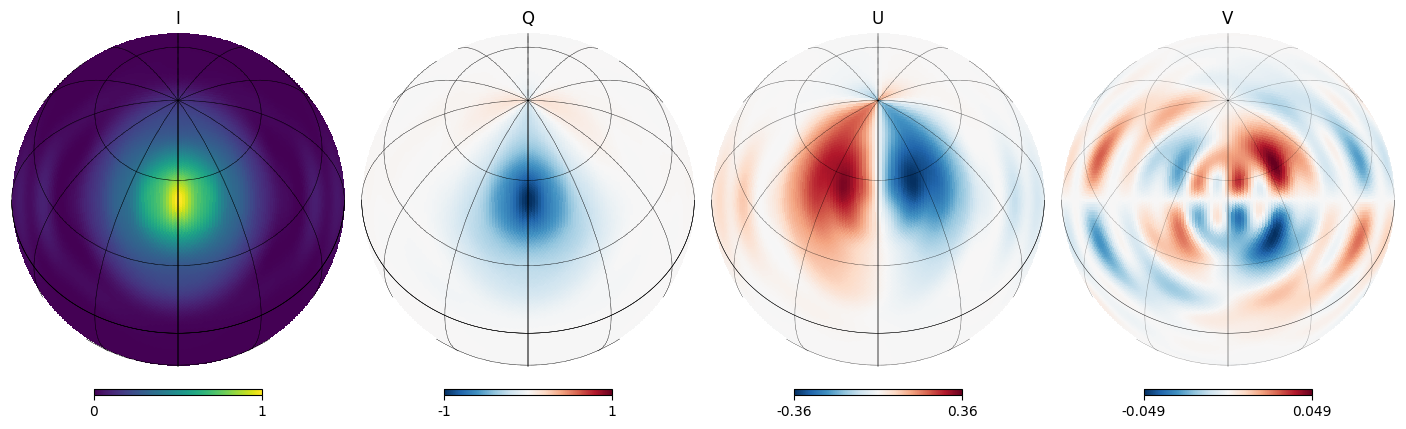

In [3]:
coords = np.stack(np.meshgrid(phi, theta[up], indexing="ij"), -1).reshape(-1, 2)
beam = E_field(coords, E[:, :, up], alignment_x=HORN_X, alignment_z=[0, 0, 1], ant_lat=LAT)  # theta > 90 deg -> 0

nside = 64
sky = np.stack(hp.pix2ang(nside, np.arange(hp.nside2npix(nside)))[::-1], -1)   # (RA, pi/2 - Dec)
B = beam.generate_auto_beam_at_LSTs([0.0], sky, freq_ind=K)[0]
B /= B[:, 0].max()

fig = plt.figure(figsize=(14, 4.2))
for p in range(4):
    lim = np.abs(B[:, p]).max()
    hp.orthview(B[:, p], rot=(0, np.rad2deg(LAT)), half_sky=True, sub=(1, 4, p + 1), fig=fig.number,
                title=STOKES[p], cmap="viridis" if p == 0 else "RdBu_r", min=0 if p == 0 else -lim, max=lim, format="%.2g")
    hp.graticule(30, 30, lw=0.3)

## 24 h drift average

The LST-averaged Stokes beams depend on Dec only. Dotted line: zenith.

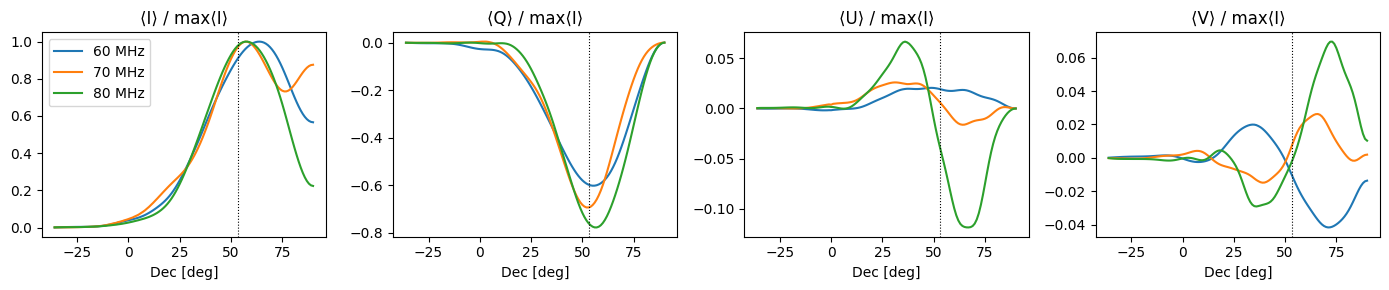

In [4]:
dec = np.deg2rad(np.arange(-36, 91))
meridian = np.stack([np.zeros_like(dec), np.pi / 2 - dec], -1)
lsts = np.arange(0, 86400, 240.0)                                    # 1 deg steps in hour angle
# mean of the Stokes beams; time_averaged=True would average E coherently
avg = np.array([beam.generate_auto_beam_at_LSTs(lsts, meridian, freq_ind=i).mean(0) for i in range(len(FREQS))])

fig, axs = plt.subplots(1, 4, figsize=(14, 3), sharex=True)
for p, ax in enumerate(axs):
    for i, f in enumerate(FREQS):
        ax.plot(np.rad2deg(dec), avg[i, :, p] / avg[i, :, 0].max(), label=f"{f} MHz")
    ax.axvline(np.rad2deg(LAT), c="k", ls=":", lw=0.8)
    ax.set(title=f"⟨{STOKES[p]}⟩ / max⟨I⟩", xlabel="Dec [deg]")
axs[0].legend()
fig.tight_layout()

## Notes

- **Horn azimuth (assumed).** `HORN_X = [1, 0, 0]`: CST $+x$ to South, polarisation East-West. The drift-averaged $\langle U\rangle$, $\langle V\rangle$ depend on it. For `HornDryGround` at 80 MHz, in units of $\max\langle I\rangle$: `[1, 0, 0]` gives $\max\lvert\langle U\rangle\rvert = 0.12$, $\max\lvert\langle V\rangle\rvert = 0.07$; `[0, 1, 0]` (East) gives $1\times10^{-3}$ and $5\times10^{-4}$. The CST intensity is mirror-symmetric about the $y$-$z$ plane to 0.1-0.3 % and about the $x$-$z$ plane to 5-8 % (60-80 MHz, $\theta \le 90^\circ$).
- **Horizon.** Only $\theta \le 90^\circ$ is passed to `E_field`; directions below the horizon interpolate to 0.
- **Drift average.** Mean of the per-LST Stokes beams. `time_averaged=True` averages $E$ over LST before forming Stokes.
- **Amplitude.** $E = 10^{\mathrm{dBi}/20}\,e^{i\,\mathrm{phase}}$, so $|E_\theta|^2 + |E_\phi|^2$ is the directivity (matches `Abs(Dir.)` to 0.2 %). $I$ is half of that (factor $\tfrac12$ in `pauli_array`); all maps are normalised to peak $I$.
- **Seam.** The exports stop at $\phi = 359^\circ$; `load_cst` repeats $\phi = 0$ at $360^\circ$ so the interpolation is periodic.
- **$V$ sign.** Follows the CST phase convention and TIBEC's $\sigma_V$; not checked against the IAU convention.
- **Check.** An ideal mirror-symmetric $y$-polarised beam through the same steps gives $\lvert\langle U\rangle\rvert, \lvert\langle V\rangle\rvert < 10^{-10}$.
- **Loader.** `load_cst` is local to this notebook; `tibec.load_efield_txt` reads the 6-column Re/Im format only.